In [1]:
from pathlib import Path
import yaml, numpy as np, pandas as pd, torch
import umap

from clearit.config import MODELS_DIR, DATASETS_DIR
from clearit.inference.utils import get_embeddings

encoder_id = "E0030"

# --- load encoder config (pretraining recipe that was saved out) ---
enc_dir = MODELS_DIR / "encoders" / encoder_id
enc_cfg = yaml.safe_load((enc_dir / "conf_enc.yaml").read_text())

dataset_name = enc_cfg["dataset_name"]
annotation_name = enc_cfg["annotation_name"]          # this is TME-A_ML6 for your caveat
index_rel_path = enc_cfg["data_index_list"]           # e.g. "indices/train/train_full01.npz"

# --- build df_samples exactly like run_pretrain.py ---
df_labels = pd.read_csv(Path(DATASETS_DIR, dataset_name, annotation_name, "labels.csv"))

arr = np.load(Path(DATASETS_DIR, dataset_name, annotation_name, index_rel_path))
files = arr.files
if len(files) == 1:
    indices = arr[files[0]]
    channels = np.zeros_like(indices, dtype=int)
else:
    indices, channels = arr[files[0]], arr[files[1]]

df_samples = df_labels.iloc[indices].reset_index(drop=True)
df_samples["channel"] = channels   # harmless for get_embeddings; keeps parity with pretrain build

# 1) remove the channel column (classification manager doesn't need it)
df_samples = df_samples.drop(columns=["channel"], errors="ignore")

# 2) collapse to unique cells (pretrain indices may repeat cells)
key_cols = ["fname", "cell_x", "cell_y"]
df_samples = (
    df_samples
      .drop_duplicates(subset=key_cols)
      .reset_index(drop=True)
)

# Optional subsample for fitting UMAP
n_umap_train = 200_000
if len(df_samples) > n_umap_train:
    df_samples = df_samples.sample(n_umap_train, random_state=0).reset_index(drop=True)

# If encoder cfg stores img_size, pass it through attrs so loader matches pretraining crop size
if "img_size" in enc_cfg:
    df_samples.attrs["img_size"] = int(enc_cfg["img_size"])


In [2]:
X_train = get_embeddings(
    df_samples,
    dataset_name=dataset_name,
    annotation_name=annotation_name,
    encoder_id=encoder_id,
    batch_size=128,
    num_workers=20,
    proj_layers=0,
).cpu().numpy()


Loaded & padded 761 images in 28.6s (26.6 f/s)
Extracted 200000 crops in 102.0s (1960.1 crops/s)


In [4]:
from sklearn.decomposition import PCA

# Choose PCA dimensionality (you can tweak this)
pca_components = min(64, X_train.shape[1])

pca = PCA(n_components=pca_components, random_state=0)
X_train_pca = pca.fit_transform(X_train)

print("PCA-transformed shape:", X_train_pca.shape)
print("Explained variance ratio (sum):", float(pca.explained_variance_ratio_.sum()))


PCA-transformed shape: (200000, 64)
Explained variance ratio (sum): 0.9183615741476714


In [5]:
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=0,
)

emb_train = umap_model.fit_transform(X_train_pca)
print("UMAP embedding:", emb_train.shape)


OMP: Info #273: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP embedding: (200000, 2)


In [6]:
import joblib
import yaml
import numpy as np
from pathlib import Path
from clearit.config import OUTPUTS_DIR

# --- define output directory ---
umap_dir = (
    Path(OUTPUTS_DIR)
    / "umap"
    / dataset_name          # e.g. "TNBC1-MxIF8"
    / annotation_name       # e.g. "TME-A_ML6"
    / encoder_id            # e.g. "E0129"
)

umap_dir.mkdir(parents=True, exist_ok=True)

# --- save UMAP model ---
umap_model_path = umap_dir / "umap_model.joblib"
joblib.dump(umap_model, umap_model_path)

# --- save embedding ---
embedding_path = umap_dir / "embedding_train.npz"
np.savez_compressed(embedding_path, emb_train=emb_train)

# --- save PCA model ---
pca_model_path = umap_dir / "pca_model.joblib"
joblib.dump(pca, pca_model_path)

meta = {
    "dataset_name": dataset_name,
    "annotation_name": annotation_name,
    "encoder_id": encoder_id,
    "num_cells": int(len(df_samples)),
    "embedding_shape": tuple(emb_train.shape),
    "pca": {
        "n_components": int(pca.n_components_),
        "explained_variance_ratio_sum": float(pca.explained_variance_ratio_.sum()),
    },
    "umap_params": {
        "n_neighbors": umap_model.n_neighbors,
        "min_dist": umap_model.min_dist,
        "metric": umap_model.metric,
    },
}

meta_path = umap_dir / "metadata.yaml"
with open(meta_path, "w") as f:
    yaml.safe_dump(meta, f)

print("Saved:")
print("  PCA model      →", pca_model_path)
print("  UMAP model     →", umap_model_path)
print("  Embedding      →", embedding_path)
print("  Metadata       →", meta_path)


Saved:
  PCA model      → /workspace/files/CLEAR-IT/outputs/umap/TNBC1-MxIF8/TME-A_ML6/E0030/pca_model.joblib
  UMAP model     → /workspace/files/CLEAR-IT/outputs/umap/TNBC1-MxIF8/TME-A_ML6/E0030/umap_model.joblib
  Embedding      → /workspace/files/CLEAR-IT/outputs/umap/TNBC1-MxIF8/TME-A_ML6/E0030/embedding_train.npz
  Metadata       → /workspace/files/CLEAR-IT/outputs/umap/TNBC1-MxIF8/TME-A_ML6/E0030/metadata.yaml


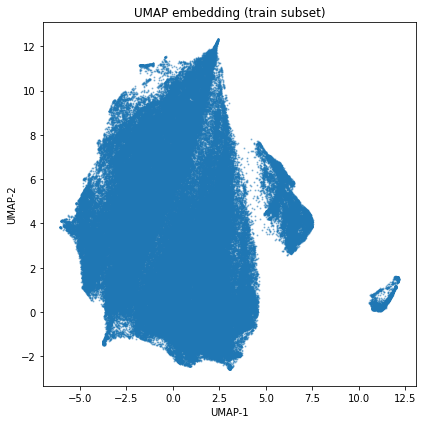

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))
plt.scatter(emb_train[:,0], emb_train[:,1], s=1, alpha=0.4)
plt.title("UMAP embedding (train subset)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()


ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not 0         [0, 0, 0, 0, 0, 0]
1         [0, 0, 0, 0, 0, 0]
2         [0, 0, 0, 0, 0, 0]
3         [0, 0, 0, 0, 0, 0]
4         [1, 0, 1, 0, 0, 0]
                 ...        
199995    [0, 1, 0, 0, 0, 0]
199996    [0, 0, 1, 0, 0, 0]
199997    [0, 0, 0, 0, 0, 0]
199998    [0, 0, 0, 0, 0, 0]
199999    [0, 0, 0, 0, 0, 0]
Name: label, Length: 200000, dtype: object

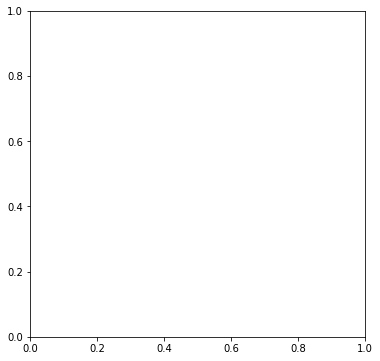

In [6]:
if "label" in df_samples.columns:
    plt.figure(figsize=(6,6))
    plt.scatter(
        emb_train[:,0], emb_train[:,1],
        c=df_samples["label"],
        cmap="tab20",
        s=2,
        alpha=0.7
    )
    plt.title("UMAP embedding (colored by label)")
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print("No 'label' column in df_samples → skipping label-colored plot.")


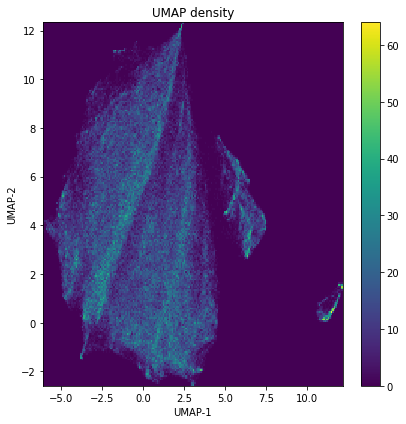

In [8]:
plt.figure(figsize=(6,6))
plt.hist2d(emb_train[:,0], emb_train[:,1], bins=200, cmap="viridis")
plt.title("UMAP density")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar()
plt.tight_layout()
plt.show()
